<a href="https://colab.research.google.com/github/FaridRash/-thermal-uav-object-detection/blob/main/Notebooks/Farid_1st.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Fetching

In [1]:
!git clone https://github.com/FaridRash/-thermal-uav-object-detection

Cloning into '-thermal-uav-object-detection'...
remote: Enumerating objects: 5779, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 5779 (delta 4), reused 3 (delta 0), pack-reused 5751 (from 3)
Receiving objects: 100% (5779/5779), 191.30 MiB | 58.15 MiB/s, done.
Resolving deltas: 100% (4/4), done.


#Libraries

In [2]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np



#Annotation checking

##Images and Annotations


🔹 Showing samples from: train


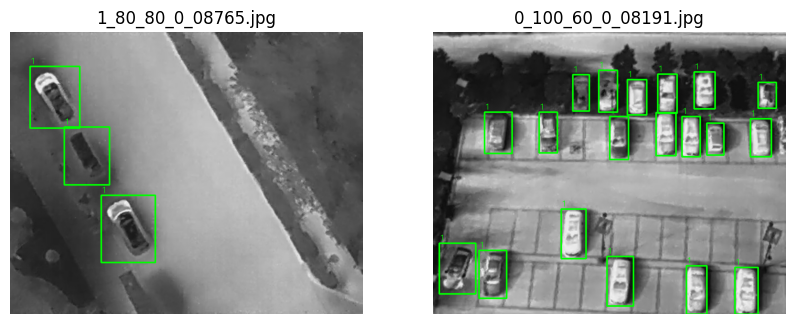


🔹 Showing samples from: val


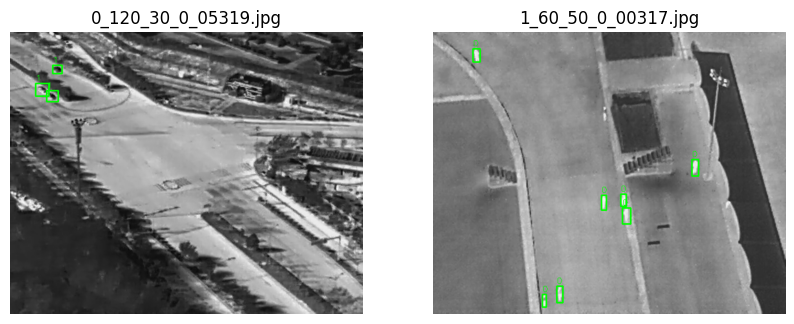


🔹 Showing samples from: test


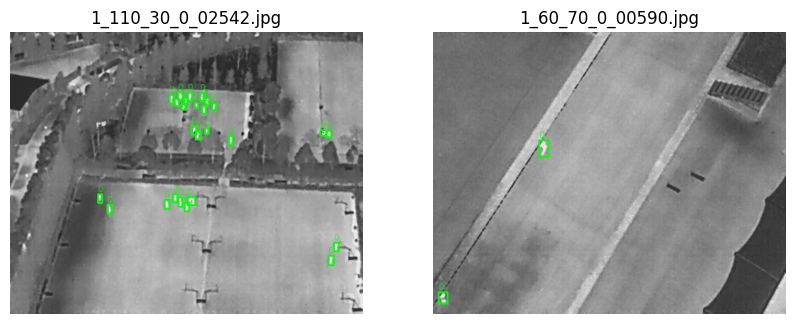

In [3]:
import random
import cv2

# Base paths
images_path = "/content/-thermal-uav-object-detection/Dataset/hit-uav/images"
labels_path = "/content/-thermal-uav-object-detection/Dataset/hit-uav/labels"

splits = ["train", "val", "test"]

def draw_yolo_boxes(image, label_file):
    h, w, _ = image.shape

    if not os.path.exists(label_file):
        return image

    with open(label_file, "r") as f:
        lines = f.readlines()

    for line in lines:
        cls, x, y, bw, bh = map(float, line.strip().split())

        # Convert YOLO → pixel coordinates
        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        # Draw box
        cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)

        # Put class id
        cv2.putText(image, f"{int(cls)}", (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

    return image


for split in splits:
    print(f"\n🔹 Showing samples from: {split}")

    img_dir = os.path.join(images_path, split)
    lbl_dir = os.path.join(labels_path, split)

    images = os.listdir(img_dir)
    selected = random.sample(images, 2)

    plt.figure(figsize=(10,5))

    for i, img_name in enumerate(selected):
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(lbl_dir, img_name.replace(".jpg", ".txt"))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = draw_yolo_boxes(image, label_path)

        plt.subplot(1, 2, i+1)
        plt.imshow(image)
        plt.title(img_name)
        plt.axis("off")

    plt.show()

##Data collection(Annotation)

###Collecting the Annotations info

In [4]:
base_path = "/content/-thermal-uav-object-detection/Dataset/hit-uav/labels"

data = []

subfolders = ["train", "test", "val"]

for sub in subfolders:
    folder_path = os.path.join(base_path, sub)

    for file in os.listdir(folder_path):
        if file.endswith(".txt"):
            file_path = os.path.join(folder_path, file)
            image_id = file.replace(".txt", "")

            with open(file_path, "r") as f:
                lines = f.readlines()

                for line in lines:
                    parts = line.strip().split()

                    # Safety check (important for corrupted labels)
                    if len(parts) != 5:
                        continue

                    class_id = int(parts[0])
                    width = float(parts[3])
                    height = float(parts[4])

                    data.append([
                        sub,           # train/test/val
                        image_id,
                        class_id,
                        width,
                        height
                    ])

df = pd.DataFrame(data, columns=[
    "subset",
    "image_id",
    "object_id",
    "width",
    "height"
])

df.head()

,subset,image_id,object_id,width,height
0,train,1_60_60_0_00539,0,0.035937,0.056641
1,train,1_60_60_0_00539,0,0.018750,0.041016
2,train,1_60_60_0_00539,0,0.037500,0.046875
3,train,1_90_70_0_08950,1,0.081250,0.195312
4,train,1_90_70_0_08950,1,0.075000,0.175781


###Convert the values

In [5]:
image_width = 640
image_height = 512
df['width_pixels'] = df['width'] * image_width
df['height_pixels'] = df['height'] * image_height
df.head()

,subset,image_id,object_id,width,height,width_pixels,height_pixels
0,train,1_60_60_0_00539,0,0.035937,0.056641,23.0,29.0
1,train,1_60_60_0_00539,0,0.018750,0.041016,12.0,21.0
2,train,1_60_60_0_00539,0,0.037500,0.046875,24.0,24.0
3,train,1_90_70_0_08950,1,0.081250,0.195312,52.0,100.0
4,train,1_90_70_0_08950,1,0.075000,0.175781,48.0,90.0


##Width and Height BoxPlots based on subsets

###Width

/tmp/ipykernel_4403/771546495.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=groups.index)


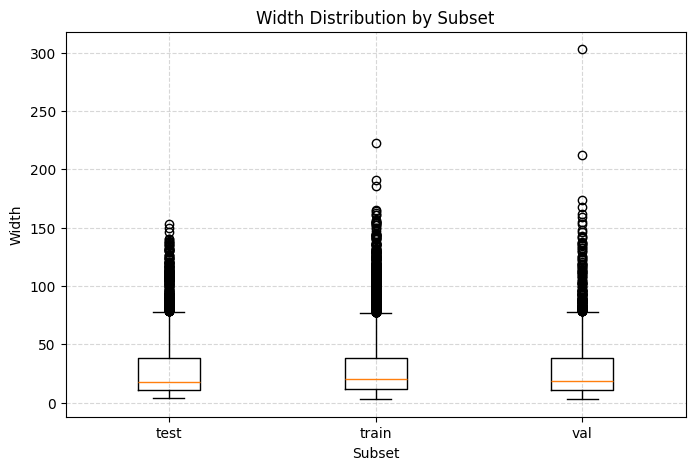

In [6]:
# Group data
groups = df.groupby('subset')['width_pixels'].apply(list)

plt.figure(figsize=(8, 5))
plt.boxplot(groups, labels=groups.index)

plt.title('Width Distribution by Subset')
plt.xlabel('Subset')
plt.ylabel('Width')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

###Height

/tmp/ipykernel_4403/2457290419.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=groups.index)


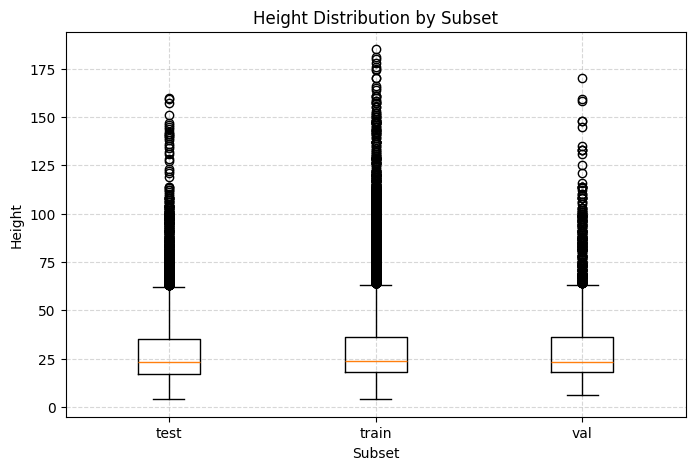

In [7]:
# Group data
groups = df.groupby('subset')['height_pixels'].apply(list)

plt.figure(figsize=(8, 5))
plt.boxplot(groups, labels=groups.index)

plt.title('Height Distribution by Subset')
plt.xlabel('Subset')
plt.ylabel('Height')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

##K-Means Clustering

###Remove invalid boxes

In [8]:
boxes = df[['width', 'height']].values

# Remove invalid boxes
boxes = boxes[(boxes[:, 0] > 0) & (boxes[:, 1] > 0)]

###IoU function

> IoU distance tells us how well an anchor can represent an object’s shape



In [9]:
def iou(box, clusters):
    """
    box: (w, h)
    clusters: (k, 2)
    """
    x = np.minimum(clusters[:, 0], box[0])  #overlap width
    y = np.minimum(clusters[:, 1], box[1])  #overlap height

    intersection = x * y
    box_area = box[0] * box[1]
    cluster_area = clusters[:, 0] * clusters[:, 1]

    union = box_area + cluster_area - intersection #total area without double counting

    return intersection / union

###K-means with IoU distance

In [10]:
def kmeans_iou(boxes, k, max_iter=100):
    np.random.seed(42)

    # Initialize clusters randomly
    clusters = boxes[np.random.choice(len(boxes), k, replace=False)]

    for _ in range(max_iter):
        distances = []

        for box in boxes:
            d = 1 - iou(box, clusters)  # IoU distance
            distances.append(d)

        distances = np.array(distances)  # (n, k)

        nearest_clusters = np.argmin(distances, axis=1)

        new_clusters = []
        for i in range(k):
            if np.sum(nearest_clusters == i) == 0:
                new_clusters.append(clusters[i])
            else:
                new_clusters.append(
                    np.median(boxes[nearest_clusters == i], axis=0)
                )

        new_clusters = np.array(new_clusters)

        if np.all(clusters == new_clusters):
            break

        clusters = new_clusters

    return clusters

###Run clustering

In [11]:
k = 9
anchors = kmeans_iou(boxes, k)

# Sort by area (important)
anchors = anchors[np.argsort(anchors[:, 0] * anchors[:, 1])]

print("Anchors (normalized):")
print(anchors)

Anchors (normalized):
[[0.015625   0.0234375 ]
 [0.0109375  0.03515625]
 [0.0140625  0.03125   ]
 [0.0171875  0.04296875]
 [0.025      0.03320312]
 [0.028125   0.05273438]
 [0.0484375  0.04296875]
 [0.059375   0.07617188]
 [0.1125     0.14453125]]


###Convert to pixels

In [12]:
anchors_px = anchors.copy()
anchors_px[:, 0] *= 640
anchors_px[:, 1] *= 512

print("Anchors (pixels):")
print(anchors_px)

Anchors (pixels):
[[10. 12.]
 [ 7. 18.]
 [ 9. 16.]
 [11. 22.]
 [16. 17.]
 [18. 27.]
 [31. 22.]
 [38. 39.]
 [72. 74.]]


###Evaluate quality

In [13]:
def avg_iou(boxes, clusters):
    return np.mean([np.max(iou(box, clusters)) for box in boxes])

score = avg_iou(boxes, anchors)
print("Average IoU:", score)

Average IoU: 0.7449500313325179


##distribution of bounding box sizes (width, height, area)

###Prepare the data

In [14]:
# assuming you already have boxes = [(w,h), ...]
df = pd.DataFrame(boxes, columns=["width", "height"])

# add area
df["area"] = df["width"] * df["height"]

###Plot distributions

####Width distribution

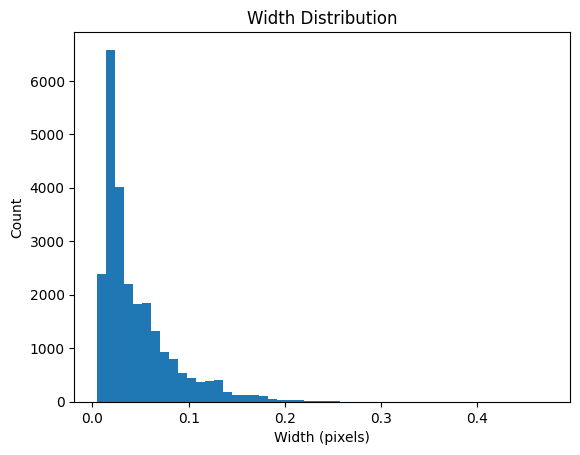

In [15]:
plt.figure()
plt.hist(df["width"], bins=50)
plt.title("Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Count")
plt.show()

####Height distribution

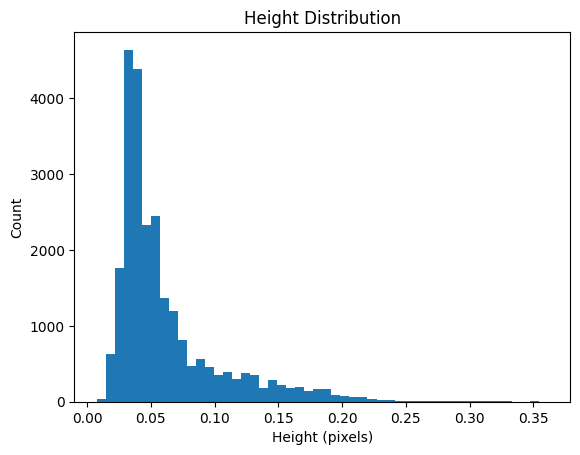

In [16]:
plt.figure()
plt.hist(df["height"], bins=50)
plt.title("Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Count")
plt.show()

####Area distribution

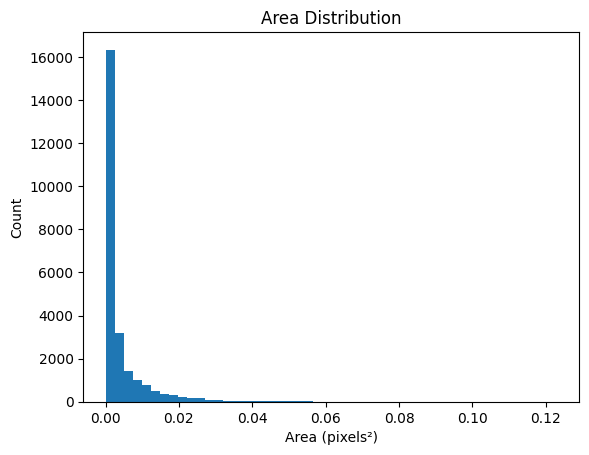

In [17]:
plt.figure()
plt.hist(df["area"], bins=50)
plt.title("Area Distribution")
plt.xlabel("Area (pixels²)")
plt.ylabel("Count")
plt.show()

###Normalize

In [18]:
IMG_W = 640
IMG_H = 512

df["width_norm"] = df["width"] / IMG_W
df["height_norm"] = df["height"] / IMG_H
df["area_norm"] = df["area"] / (IMG_W * IMG_H)

####Plot normalized area

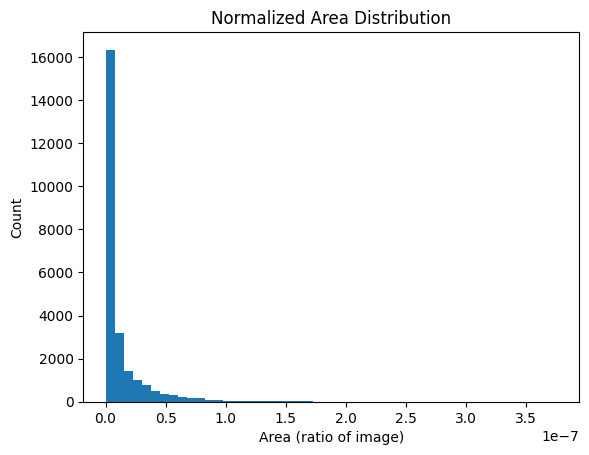

In [19]:
plt.figure()
plt.hist(df["area_norm"], bins=50)
plt.title("Normalized Area Distribution")
plt.xlabel("Area (ratio of image)")
plt.ylabel("Count")
plt.show()